# Construction of a Multi-Asset Index with Volatility Control and Leverage  


This notebook presents the construction and analysis of a multi-asset index that incorporates volatility control and leverage. By combining a diverse set of asset classes—including equities, bonds, commodities, and real estate—the objective is to create a robust and balanced portfolio. The methodology involves downloading historical price data, calculating returns, and applying a systematic allocation process that targets a specific volatility level through dynamic rebalancing and leverage adjustment. The notebook also provides visualizations and key performance metrics to evaluate the effectiveness of the strategy, offering insights into risk management and portfolio optimization in a multi-asset context

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

In [64]:
# List of representative ETF tickers for different asset classes
tickers = [
    "SPY",  # S&P 500
    "EWJ",  # Japan
    "VGK",  # Europe
    "EEM",  # Emerging Markets
    "QQQ",  # Nasdaq 100
    "IEF",  # US Bonds 7-10 years
    "TLT",  # US Bonds 20+ years
    "LQD",  # Corporate Bonds
    "EMB",  # Emerging Market Bonds
    "GLD",  # Gold
    "DBC",  # Commodities
    "VNQ",  # US Real Estate
    "SHV",  # Short-term Cash
    "BIL"   # T-Bills (cash equivalent)
]

# Download adjusted prices for 10 years
prices = yf.download(tickers, start="2010-01-01", end="2025-01-01")['Close']

# Show the first 5 rows
display(prices.head())

C:\Users\trib2\AppData\Local\Temp\ipykernel_37212\1512796864.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start="2010-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  14 of 14 completed


Ticker,BIL,DBC,EEM,EMB,EWJ,GLD,IEF,LQD,QQQ,SHV,SPY,TLT,VGK,VNQ
Date,,,,,,,,,,,,,,
2010-01-04,74.759201,21.338842,30.351517,47.674023,29.801046,109.800003,62.159664,58.328854,40.341587,89.277481,85.027954,56.575085,28.678188,23.803867
2010-01-05,74.742882,21.364208,30.571815,47.964008,29.980038,109.699997,62.432610,58.607399,40.341587,89.245140,85.253059,56.940392,28.632261,23.777153
2010-01-06,74.742882,21.744656,30.635773,48.029480,30.099367,111.510002,62.180637,58.434692,40.098270,89.253212,85.313042,56.178196,28.804483,23.734402
2010-01-07,74.742882,21.474113,30.458099,47.781593,29.830891,110.820000,62.180637,58.507065,40.124317,89.253212,85.673187,56.272663,28.620783,23.990883
2010-01-08,74.742882,21.457203,30.699732,47.837708,30.188848,111.370003,62.257633,58.635273,40.454563,89.285637,85.958305,56.247471,28.907791,23.814556


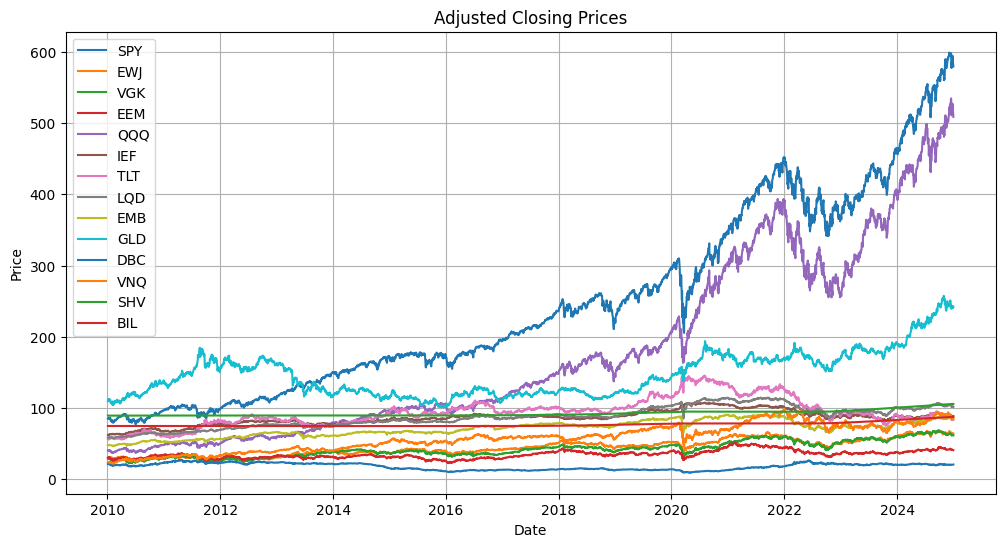

In [65]:
# Plot data
plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(prices[ticker], label=ticker)

plt.title('Adjusted Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
returns = prices.pct_change().dropna()
display(returns.head(5))

Ticker,BIL,DBC,EEM,EMB,EWJ,GLD,IEF,LQD,QQQ,SHV,SPY,TLT,VGK,VNQ
Date,,,,,,,,,,,,,,
2010-01-05,-0.000218,0.001189,0.007258,0.006083,0.006006,-0.000911,0.004391,0.004775,0.000000,-0.000362,0.002647,0.006457,-0.001601,-0.001122
2010-01-06,0.000000,0.017808,0.002092,0.001365,0.003980,0.016500,-0.004036,-0.002947,-0.006031,0.000090,0.000704,-0.013386,0.006015,-0.001798
2010-01-07,0.000000,-0.012442,-0.005800,-0.005161,-0.008920,-0.006188,0.000000,0.001239,0.000650,0.000000,0.004221,0.001682,-0.006377,0.010806
2010-01-08,0.000000,-0.000787,0.007933,0.001174,0.012000,0.004963,0.001238,0.002191,0.008231,0.000363,0.003328,-0.000448,0.010028,-0.007350
2010-01-11,0.000000,-0.003152,-0.002083,0.007626,0.008893,0.013289,0.000675,0.001045,-0.004081,0.000000,0.001396,-0.005487,0.007943,0.005833


In [67]:
# Function to compute Compound Annual Growth Rate (CAGR)
def compute_cagr(price, ann_multiple=252):
    n = len(price)
    cagr = (price.iloc[-1] / price.iloc[0]) ** (ann_multiple / n) - 1
    return cagr

# Function to compute Volatility
def compute_vol(price, ann_multiple=252):
    ret = price / price.shift(1) - 1  # Calculate returns
    n = len(price)  # Get the length of the time series
    mu = np.nanmean(ret)  # Calculate the mean
    sigma_daily = np.sqrt(np.nansum((ret - mu) ** 2) / (n - 1))  # Calculate daily volatility
    sigma = np.sqrt(ann_multiple) * sigma_daily  # Annualize the volatility
    return sigma

# Function to compute Sharpe Ratio
def compute_sr(price, ret_without_risk=0.00, ann_multiple=252):
    cagr = compute_cagr(price, ann_multiple)  # CAGR
    vol = compute_vol(price, ann_multiple)  # Volatility
    sr = (cagr - ret_without_risk) / vol
    return sr

Covariance matrix :
 Ticker           BIL           DBC           EEM           EMB           EWJ  \
Ticker                                                                         
BIL     2.830901e-08 -6.717758e-08 -1.454638e-08 -1.790412e-08  7.534070e-09   
DBC    -6.717758e-08  1.177204e-04  6.795878e-05  1.801906e-05  4.099066e-05   
EEM    -1.454638e-08  6.795878e-05  1.837169e-04  4.227201e-05  1.039366e-04   
EMB    -1.790412e-08  1.801906e-05  4.227201e-05  3.347424e-05  2.786185e-05   
EWJ     7.534070e-09  4.099066e-05  1.039366e-04  2.786185e-05  1.230076e-04   
GLD     4.165785e-09  3.327268e-05  2.253939e-05  1.335518e-05  1.003252e-05   
IEF     2.050514e-08 -8.210186e-06 -1.273120e-05  6.842430e-06 -8.169453e-06   
LQD     3.776808e-09  2.410005e-06  1.099779e-05  1.682674e-05  8.172711e-06   
QQQ    -2.382604e-08  4.490106e-05  1.276490e-04  3.500716e-05  9.415562e-05   
SHV     9.709442e-09 -7.744708e-08 -6.330927e-08  6.445123e-08 -6.691784e-09   
SPY    -3.002962e-0

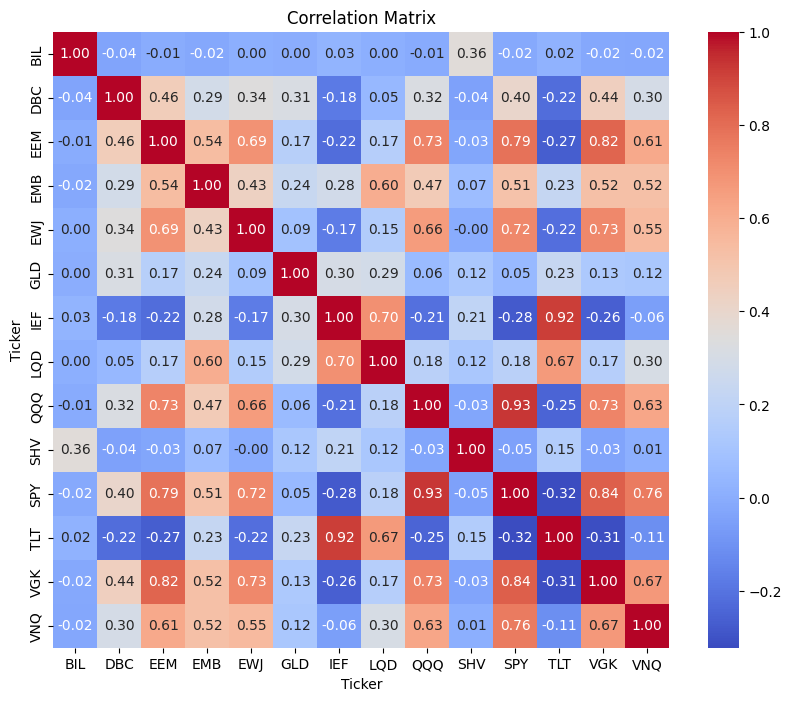

In [68]:
volatilites = prices.apply(compute_vol)

cov_mat = returns.cov()
corr_mat = returns.corr()

print('Covariance matrix :\n', cov_mat)
# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()

MAX_LEVERAGE: 2.0x
Unlevered portfolio vol  → min: 0.42%  |  avg: 0.74%  |  max: 1.31%
Max achievable TARGVOL   → min: 0.84%  |  avg: 1.47%  |  max: 2.61%

→ With MAX_LEVERAGE=2.0x, a safe TARGVOL target is up to 0.84% (worst-case quarter)


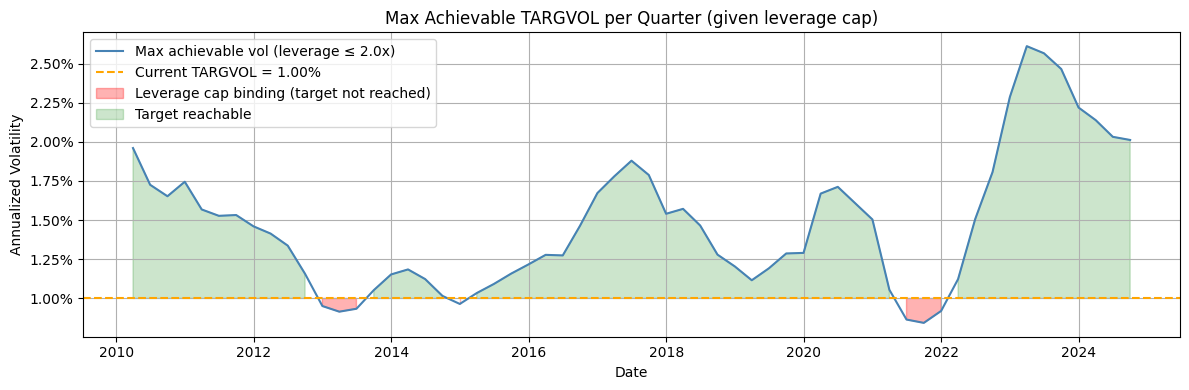

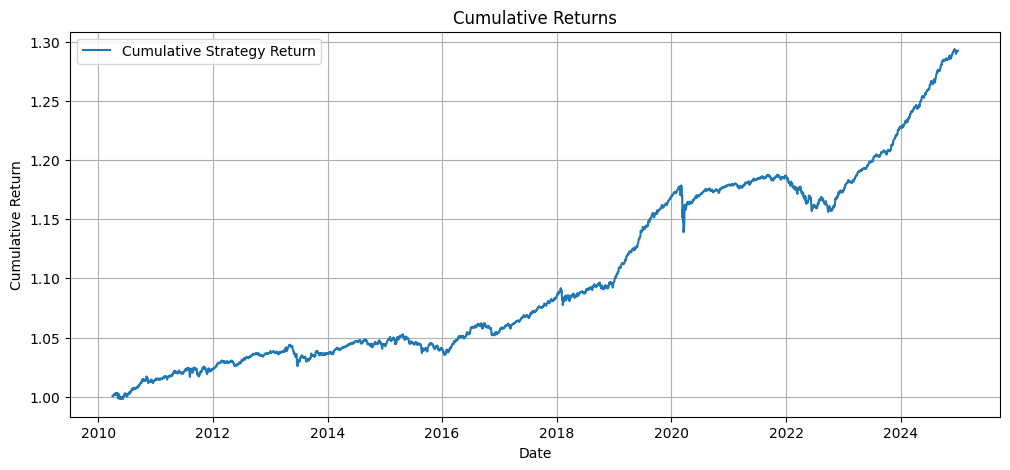

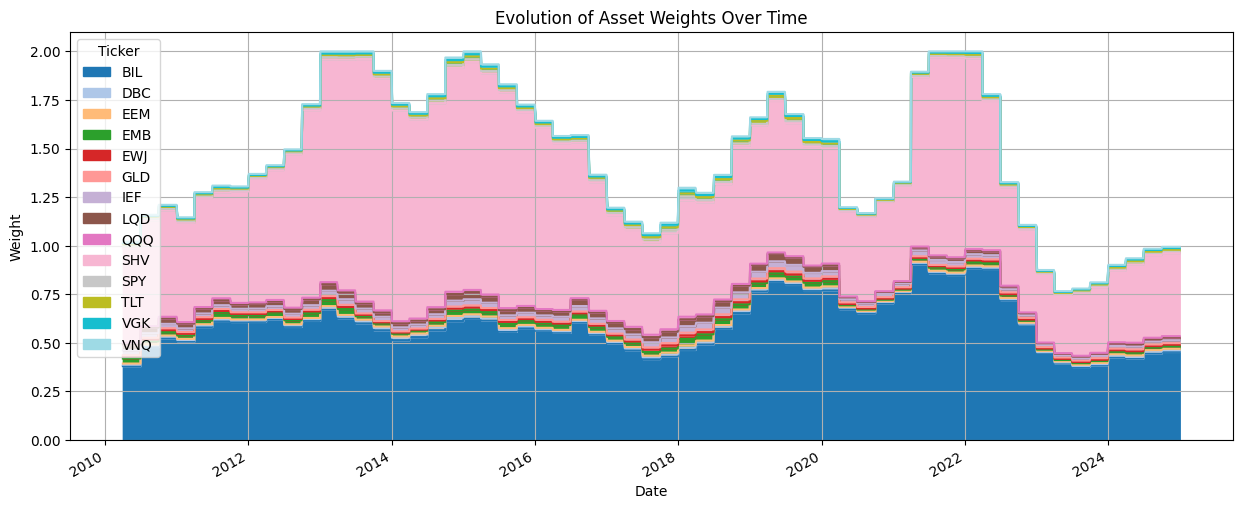

In [69]:
TARGVOL = 0.01
MAX_LEVERAGE = 2.0  # Maximum allowed leverage

# Rebalancing dates (quarterly)
rebalancing_dates = returns.resample('QE').last().index

# Initialize dataframe to store strategy returns and weights
strategy_ret = pd.DataFrame(index=returns.index, columns=['Strategy_ret'])
weights_df = pd.DataFrame(index=returns.index, columns=returns.columns)

# Track max achievable TARGVOL per period
max_achievable_vol_series = pd.Series(index=rebalancing_dates[:-1], dtype=float)
unlevered_vol_series = pd.Series(index=rebalancing_dates[:-1], dtype=float)

for index_t in range(len(rebalancing_dates) - 1):
    t = rebalancing_dates[index_t]

    # Data for the past year
    past_year_returns = returns.loc[t - pd.DateOffset(years=1):t]

    # Calculate annualized covariance for the past year
    ex_ante_cov = past_year_returns.cov() * 252

    # Calculate annualized volatilities
    vol = np.sqrt(np.diag(ex_ante_cov.values))

    # Equal risk weights
    weights = 1 / vol
    weights /= weights.sum()

    # Ex ante volatility of strategy (unlevered)
    strategy_vol = np.sqrt(weights @ ex_ante_cov @ weights)
    unlevered_vol_series.iloc[index_t] = strategy_vol

    # Max achievable TARGVOL given MAX_LEVERAGE
    max_achievable_vol_series.iloc[index_t] = MAX_LEVERAGE * strategy_vol

    # Compute leverage (capped at MAX_LEVERAGE)
    leverage = min(TARGVOL / strategy_vol, MAX_LEVERAGE)

    # Adjusted weights
    adjusted_weights = weights * leverage

    # Date range between two rebalancing dates
    index_return = slice(rebalancing_dates[index_t] + pd.Timedelta(days=1),
                         rebalancing_dates[index_t + 1])

    # Apply weights to compute returns
    strategy_ret.loc[index_return, 'Strategy_ret'] = returns.loc[index_return].dot(adjusted_weights)

    # Store weights for each date in the period
    for date in returns.loc[index_return].index:
        weights_df.loc[date] = adjusted_weights


strategy_ret.dropna(inplace=True)
weights_df.dropna(inplace=True)

# --- Max achievable TARGVOL summary ---
print(f'MAX_LEVERAGE: {MAX_LEVERAGE:.1f}x')
print(f'Unlevered portfolio vol  → min: {unlevered_vol_series.min():.2%}  |  avg: {unlevered_vol_series.mean():.2%}  |  max: {unlevered_vol_series.max():.2%}')
print(f'Max achievable TARGVOL   → min: {max_achievable_vol_series.min():.2%}  |  avg: {max_achievable_vol_series.mean():.2%}  |  max: {max_achievable_vol_series.max():.2%}')
print(f'\n→ With MAX_LEVERAGE={MAX_LEVERAGE:.1f}x, a safe TARGVOL target is up to {max_achievable_vol_series.min():.2%} (worst-case quarter)')

# --- Plot max achievable vol over time ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(max_achievable_vol_series.index, max_achievable_vol_series.values, label=f'Max achievable vol (leverage ≤ {MAX_LEVERAGE:.1f}x)', color='steelblue')
ax.axhline(TARGVOL, color='orange', linestyle='--', label=f'Current TARGVOL = {TARGVOL:.2%}')
ax.fill_between(max_achievable_vol_series.index, max_achievable_vol_series.values, TARGVOL,
                where=max_achievable_vol_series.values < TARGVOL,
                color='red', alpha=0.3, label='Leverage cap binding (target not reached)')
ax.fill_between(max_achievable_vol_series.index, max_achievable_vol_series.values, TARGVOL,
                where=max_achievable_vol_series.values >= TARGVOL,
                color='green', alpha=0.2, label='Target reachable')
ax.set_title('Max Achievable TARGVOL per Quarter (given leverage cap)')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2%}'))
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Plot cumulative returns ---
cumulative_returns = (1 + strategy_ret).cumprod()
plt.figure(figsize=(12, 5))
plt.plot(cumulative_returns, label='Cumulative Strategy Return')
plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.legend()
plt.show()

# --- Plot weights evolution ---
weights_df.plot(kind='area', stacked=True, cmap='tab20', figsize=(15, 6), title='Evolution of Asset Weights Over Time')
plt.xlabel('Date')
plt.ylabel('Weight')
plt.grid(True)
plt.show()


In [70]:
weights_df['total'] = weights_df.sum(axis=1)
weights_df['total']

Date
2010-04-01    1.020194
2010-04-05    1.020194
2010-04-06    1.020194
2010-04-07    1.020194
2010-04-08    1.020194
                ...   
2024-12-24    0.994017
2024-12-26    0.994017
2024-12-27    0.994017
2024-12-30    0.994017
2024-12-31    0.994017
Name: total, Length: 3713, dtype: object

CAGR                 1.75%
Annualized Vol       1.20%
Sharpe Ratio          1.45
Sortino Ratio         1.67
Max Drawdown        -3.36%
Calmar Ratio          0.52
VaR 95% (daily)     -0.10%
CVaR 95% (daily)    -0.17%
Best Day             0.76%
Worst Day           -1.01%
Win Rate            57.69%


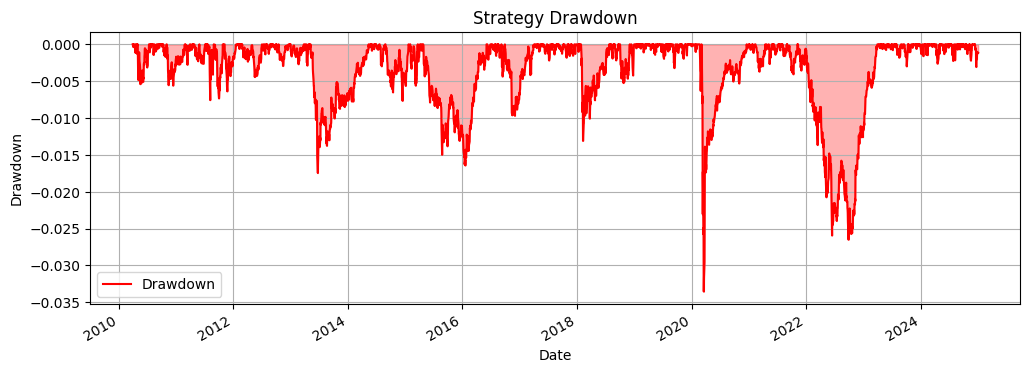

In [71]:
ann_multiple = 252
risk_free_rate = 0.0

ret = strategy_ret['Strategy_ret'].astype(float)

# --- CAGR ---
final_cum_return = cumulative_returns.values[-1].item()
CAGR = final_cum_return ** (ann_multiple / len(ret)) - 1

# --- Volatility ---
daily_vol = ret.std()
annualized_vol = daily_vol * np.sqrt(ann_multiple)

# --- Sharpe Ratio ---
annualized_return = ret.mean() * ann_multiple
SR = (annualized_return - risk_free_rate) / annualized_vol

# --- Sortino Ratio ---
downside_returns = ret[ret < 0]
downside_vol = downside_returns.std() * np.sqrt(ann_multiple)
sortino = (annualized_return - risk_free_rate) / downside_vol

# --- Max Drawdown ---
cum = (1 + ret).cumprod()
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# --- Calmar Ratio ---
calmar = CAGR / abs(max_drawdown)

# --- VaR and CVaR (95%) ---
var_95 = ret.quantile(0.05)
cvar_95 = ret[ret <= var_95].mean()

# --- Best / Worst day ---
best_day = ret.max()
worst_day = ret.min()

# --- Win rate ---
win_rate = (ret > 0).mean()

# --- Summary table ---
stats = pd.Series({
    'CAGR':               f'{CAGR:.2%}',
    'Annualized Vol':     f'{annualized_vol:.2%}',
    'Sharpe Ratio':       f'{SR:.2f}',
    'Sortino Ratio':      f'{sortino:.2f}',
    'Max Drawdown':       f'{max_drawdown:.2%}',
    'Calmar Ratio':       f'{calmar:.2f}',
    'VaR 95% (daily)':    f'{var_95:.2%}',
    'CVaR 95% (daily)':   f'{cvar_95:.2%}',
    'Best Day':           f'{best_day:.2%}',
    'Worst Day':          f'{worst_day:.2%}',
    'Win Rate':           f'{win_rate:.2%}',
}, name='Strategy')

print(stats.to_string())

# --- Drawdown plot ---
plt.figure(figsize=(12, 4))
drawdown.plot(color='red', label='Drawdown')
plt.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
plt.title('Strategy Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.grid(True)
plt.legend()
plt.show()
